In [1]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)-8s %(name)s: %(message)s",
    datefmt="%H:%M:%S",
)

import tanglepack
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%load_ext autoreload
%autoreload 2

/mnt/c/Users/etccu/Documents/TanglePack/env/lib/python3.12/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [2]:
def henon_map(point):
    """
    Defines the henon map for binary horshoe parameters to test basic functionality
    """

    k, b = (2, 1)

    x = point[0]
    y = point[1]

    return np.array([y - k + x**2, -b * x])


def henon_map_inverse(point):
    """Defines the inverse henon map for"""

    k, b = (2, 1)

    x = point[0]
    y = point[1]

    return np.array([-y / b, x + k - (y**2) / (b**2)])

In [7]:
"""initialize the manifolds (must be redone before running each cell below)"""

# initialize the workbench
workbench = tanglepack.TangleWorkbench(henon_map, henon_map_inverse)

initial_guess = [[0, 1], [-1, 0], [-1, 1]]

initial_guess_zero = [4, -4]

# find the fixed point
fixed_point = workbench.construct_fixed_point(initial_guess)
fixed_point_zero = workbench.construct_fixed_point(initial_guess_zero)

print(f"The fixed point is: {fixed_point.coordinates}")


approx_dir = {"unstable": np.array([0, -1]), "stable": np.array([-1, -1])}

workbench.orient_eigenvectors(fixed_point, approx_dir)

approx_dir = {"unstable": [-1, 0], "stable": [0, 1]}

workbench.orient_eigenvectors(fixed_point_zero, approx_dir)
# orient the eigenvectors properly

# get the initial segments
(unstable_segments, stable_segments) = workbench.initialize_both_manifolds(fixed_point)
(unstable_segments_zero, stable_segments_zero) = workbench.initialize_both_manifolds(fixed_point_zero)

[autoreload of tanglepack.TangleWorkbench failed: Traceback (most recent call last):
  File "/mnt/c/Users/etccu/Documents/TanglePack/env/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/mnt/c/Users/etccu/Documents/TanglePack/env/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1133, in get_code
  File "<frozen importlib._bootstrap_external>", line 1063, in source_to_code
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/mnt/c/Users/etccu/Documents/TanglePack/src/tanglepack/Tangle

eigenvalues: [3.73205081 0.26794919]
eigenvalues: [0.26794919 3.73205081]
eigenvalues: [3.73205081 0.26794919]
eigenvalues: [5.27457964 0.18958857]
The fixed point is: [[-1.97042575e-12  1.00000000e+00]
 [-1.00000000e+00  0.00000000e+00]
 [-1.00000000e+00  1.00000000e+00]]


11:14:04 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
11:14:04 INFO     tanglepack.ManifoldMachine: 2 NUMBER OF CURRENT POINTS
11:14:04 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
11:14:04 INFO     tanglepack.ManifoldMachine: 3 NUMBER OF CURRENT POINTS
11:14:04 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
11:14:04 INFO     tanglepack.ManifoldMachine: 3 NUMBER OF CURRENT POINTS
11:14:04 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
11:14:04 INFO     tanglepack.ManifoldMachine: 3 NUMBER OF CURRENT POINTS
11:14:04 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
11:14:04 INFO     tanglepack.ManifoldMachine: 4 NUMBER OF CURRENT POINTS
11:14:04 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
11:14:04 INFO     tanglepack.ManifoldMachine: 4 NUMBER OF CURRENT POINTS
11:14:04 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
11:14:04 

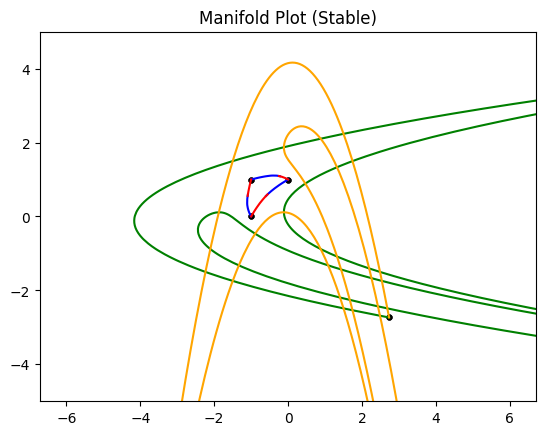

In [8]:
"""growing based on the number of iterates"""

workbench.grow_n_times(fixed_point, "unstable", num_iterations=7)
workbench.plot_tangle(fixed_point, "unstable")

workbench.grow_n_times(fixed_point, "stable", num_iterations=6)
workbench.plot_tangle(fixed_point, "stable", color='r')

workbench.grow_n_times(fixed_point_zero, "unstable", num_iterations=6)
workbench.plot_tangle(fixed_point_zero, "unstable", color='green')

workbench.grow_n_times(fixed_point_zero, "stable", num_iterations=6)
workbench.plot_tangle(fixed_point_zero, "stable", color='orange')

plt.xlim([-5, 5])
plt.ylim([-5, 5])

# plt.xlim([-2, 2])
# plt.ylim([-2, 2])
plt.show()

10:05:59 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
10:05:59 INFO     tanglepack.ManifoldMachine: 2 NUMBER OF CURRENT POINTS
10:05:59 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
10:05:59 INFO     tanglepack.ManifoldMachine: 3 NUMBER OF CURRENT POINTS
10:05:59 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
10:05:59 INFO     tanglepack.ManifoldMachine: 3 NUMBER OF CURRENT POINTS
10:05:59 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
10:05:59 INFO     tanglepack.ManifoldMachine: 3 NUMBER OF CURRENT POINTS
10:05:59 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
10:05:59 INFO     tanglepack.ManifoldMachine: 4 NUMBER OF CURRENT POINTS
10:05:59 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
10:05:59 INFO     tanglepack.ManifoldMachine: 4 NUMBER OF CURRENT POINTS
10:05:59 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
10:05:59 

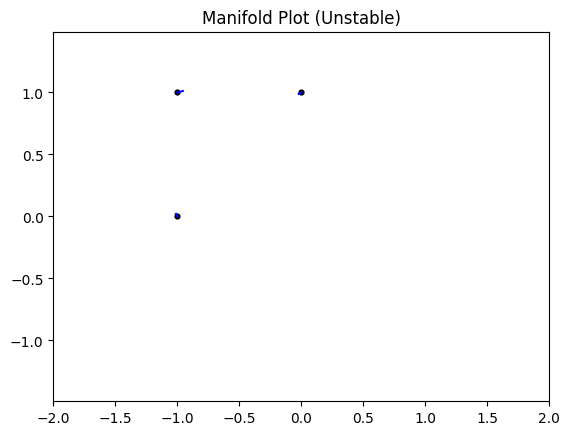

In [ ]:
"""growing based on the number of iterates"""

workbench.grow_n_times(fixed_point, "unstable", num_iterations=6)
workbench.plot_tangle(fixed_point, "unstable")

# workbench.grow_n_times(fixed_point_zero, "unstable", num_iterations=6)
# workbench.plot_tangle(fixed_point_zero, "unstable")

# plt.xlim([-1.5, 1.5])
# plt.ylim([-1.5, 1.5])

plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.show()

09:50:26 WARNING  matplotlib.axes._base: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


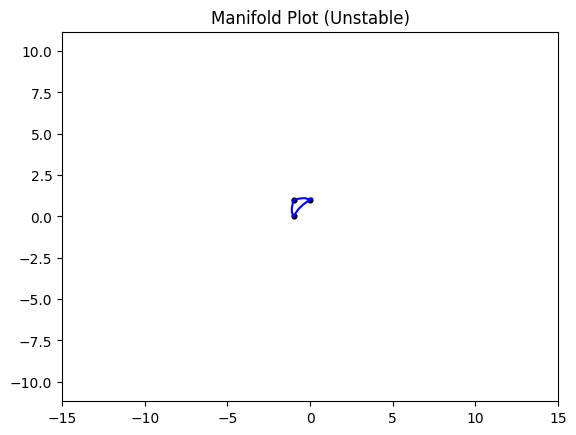

In [6]:
"""growing until the desired cdist is reached"""

workbench.grow_until_arclength(fixed_point, "unstable", length=50)
workbench.plot_tangle(fixed_point, "unstable")

plt.xlim([-15, 15])
plt.ylim([-15, 15])

plt.show()

In [110]:
"growing until the manifold turns around"

workbench.grow_until_turnaround(fixed_point, "unstable")
workbench.plot_tangle(fixed_point, "unstable")

plt.xlim([-15, 15])
plt.ylim([-15, 15])

plt.show()

22:05:43 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:05:43 INFO     tanglepack.ManifoldMachine: 2 NUMBER OF CURRENT POINTS
22:05:43 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:05:43 INFO     tanglepack.ManifoldMachine: 2 NUMBER OF CURRENT POINTS
22:05:43 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:05:43 INFO     tanglepack.ManifoldMachine: 3 NUMBER OF CURRENT POINTS
22:05:43 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:05:43 INFO     tanglepack.ManifoldMachine: 3 NUMBER OF CURRENT POINTS
22:05:43 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:05:43 INFO     tanglepack.ManifoldMachine: 3 NUMBER OF CURRENT POINTS
22:05:43 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:05:43 INFO     tanglepack.ManifoldMachine: 3 NUMBER OF CURRENT POINTS
22:05:43 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:05:43 

ValueError: Two nodes have the same cdist but are different objects 

                          cdists: 73.83674850028234, 73.83674850028234 

                          nodes: <tanglepack.Point.Point object at 0x7fe49e3b61e0>, <tanglepack.Point.Point object at 0x7fe49e21f6e0>
                          coordinates: [ 1.62671096 -1.41780824], [ 1.60318347 -1.40948669]
                          

22:14:34 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:14:34 INFO     tanglepack.ManifoldMachine: 2 NUMBER OF CURRENT POINTS
22:14:34 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:14:34 INFO     tanglepack.ManifoldMachine: 2 NUMBER OF CURRENT POINTS
22:14:34 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:14:34 INFO     tanglepack.ManifoldMachine: 3 NUMBER OF CURRENT POINTS
22:14:34 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:14:34 INFO     tanglepack.ManifoldMachine: 3 NUMBER OF CURRENT POINTS
22:14:34 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:14:34 INFO     tanglepack.ManifoldMachine: 3 NUMBER OF CURRENT POINTS
22:14:34 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:14:34 INFO     tanglepack.ManifoldMachine: 3 NUMBER OF CURRENT POINTS
22:14:34 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:14:34 

current intersections 3


22:14:34 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:14:34 INFO     tanglepack.ManifoldMachine: 5 NUMBER OF CURRENT POINTS
22:14:34 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:14:34 INFO     tanglepack.ManifoldMachine: 5 NUMBER OF CURRENT POINTS
22:14:34 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:14:34 INFO     tanglepack.ManifoldMachine: 6 NUMBER OF CURRENT POINTS
22:14:34 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:14:34 INFO     tanglepack.ManifoldMachine: 6 NUMBER OF CURRENT POINTS
22:14:34 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:14:34 INFO     tanglepack.ManifoldMachine: 6 NUMBER OF CURRENT POINTS
22:14:34 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:14:34 INFO     tanglepack.ManifoldMachine: 6 NUMBER OF CURRENT POINTS
22:14:34 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
22:14:34 

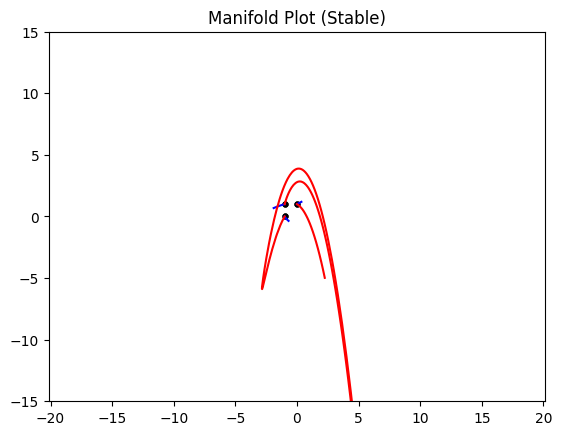

In [120]:
"growing until one manifold intersects the other"

workbench.grow_until_arclength(fixed_point, "stable", length=50)
workbench.grown_until_intersection(fixed_point, "unstable")

workbench.plot_tangle(fixed_point, "unstable")
workbench.plot_tangle(fixed_point, "stable", color="r")

plt.xlim([-15, 15])
plt.ylim([-15, 15])

plt.show()